In [52]:
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap, BoundaryNorm
from shapely.geometry import Point
from scipy.stats import gamma,norm,fisk,wilcoxon
from sklearn.cluster import KMeans
import re
import sys
from pathlib import Path
import logging
from glob import glob

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [2]:
# Configuration
config = {
    'input_data': project_root / 'data' / 'input_data' / 'for_report' ,
    'gap_filled_canswe_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' /'bow_swe_gapfilled_data_only.nc',
    'canswe_original_data' : project_root / 'data' / 'output_data' / 'for_paper'/'FROSTBITE' / 'bow_canswe_selected_fixed.nc',
    'shapefile': project_root / 'data' / 'input_data' / 'shapefiles'/'BowRiverBasin'/'Bow_elevation_combined.shp',
    'output_plots': project_root / 'data' / 'output_data' / 'for_report'}

# Data preparation
Functions

In [3]:
def extract_station_id(filepath):
    """
    Extract station id from filenames like:
    porExtract_AB_05BB803_PC_CmdTotal.Merged.C.csv
    """
    fname = Path(filepath).name
    m = re.search(r'AB_([A-Z0-9]+)_', fname)
    return m.group(1) if m else fname

def read_alberta_timeseries(filepath, value_name):
    """
    Read Alberta web-export CSV with 22-line header.
    Returns columns: time, station_id, <value_name>
    """
    station_id = extract_station_id(filepath)

    df = pd.read_csv(filepath, skiprows=22)
    df.columns = [c.strip() for c in df.columns]

    # combine Date and Time
    df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
    df = df.dropna(subset=['time']).copy()

    # value column
    value_col = [c for c in df.columns if 'Value' in c][0]

    df = df[['time', value_col]].rename(columns={value_col: value_name})
    df['station_id'] = station_id

    return df[['time', 'station_id', value_name]]

def daily_aggregate(df, value_col, how='sum'):
    """
    Aggregate to daily data by station.
    """
    if how == 'sum':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .sum()
              .reset_index()
        )
    elif how == 'mean':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .mean()
              .reset_index()
        )
    elif how == 'last':
        out = (
            df.set_index('time')
              .groupby('station_id')[value_col]
              .resample('D')
              .last()
              .reset_index()
        )
    else:
        raise ValueError("how must be 'sum', 'mean', or 'last'")

    return out

def add_seasonal_year_oct_may(df, time_col='time'):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    out['month'] = out[time_col].dt.month
    out['year'] = out[time_col].dt.year

    out = out[out['month'].isin([10, 11, 12, 1, 2, 3, 4, 5])].copy()

    out['Seasonal_Year'] = out['year']
    out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'Seasonal_Year'] = (
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
    )

    return out

def combine_daily_swe_precip(folder, swe_pattern='*SW*.csv', precip_pattern='*PC*.csv',
                             swe_agg='last', precip_agg='sum', add_season_year=True):
    folder = Path(folder)

    swe_files = sorted(glob(str(folder / swe_pattern)))
    precip_files = sorted(glob(str(folder / precip_pattern)))

    if not swe_files:
        raise FileNotFoundError(f"No SWE files found with pattern: {swe_pattern}")
    if not precip_files:
        raise FileNotFoundError(f"No precip files found with pattern: {precip_pattern}")

    swe_all = pd.concat(
        [read_alberta_timeseries(f, 'SWE') for f in swe_files],
        ignore_index=True
    )
    precip_all = pd.concat(
        [read_alberta_timeseries(f, 'Precipitation') for f in precip_files],
        ignore_index=True
    )

    swe_daily = daily_aggregate(swe_all, 'SWE', how=swe_agg)
    precip_daily = daily_aggregate(precip_all, 'Precipitation', how=precip_agg)

    combined = pd.merge(
        swe_daily,
        precip_daily,
        on=['time', 'station_id'],
        how='outer'
    ).sort_values(['station_id', 'time']).reset_index(drop=True)

    if add_season_year:
        combined = add_seasonal_year_oct_may(combined, time_col='time')

    return combined

In [4]:
folder = config['input_data']

combined_daily_df = combine_daily_swe_precip(
    folder=folder,
    swe_agg='last',
    precip_agg='sum',
    add_season_year=True
)

display(combined_daily_df.head())
print(combined_daily_df.columns)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
0,05BB803,2025-03-10,320.0,11.9,3,2025,2024
1,05BB803,2025-03-11,322.0,1.4,3,2025,2024
2,05BB803,2025-03-12,324.0,2.1,3,2025,2024
3,05BB803,2025-03-13,342.0,18.3,3,2025,2024
4,05BB803,2025-03-14,347.0,5.0,3,2025,2024


Index(['station_id', 'time', 'SWE', 'Precipitation', 'month', 'year',
       'Seasonal_Year'],
      dtype='object')


In [5]:
# save combined_daily_df to output folder for later use
output_path = config['output_plots'] / 'combined_daily_swe_precip.csv'
combined_daily_df.to_csv(output_path, index=False)

In [6]:
# extract data for season year 2025
season_2025_df = combined_daily_df[combined_daily_df['Seasonal_Year'] == 2025].copy()

# add prefix 'ALE-' and 'P' to station_id
season_2025_df['station_id'] = 'ALE-' + season_2025_df['station_id'] + 'P'
display(season_2025_df)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
205,ALE-05BB803P,2025-10-01,1.0,2.8,10,2025,2025
206,ALE-05BB803P,2025-10-02,4.0,0.6,10,2025,2025
207,ALE-05BB803P,2025-10-03,1.0,0.0,10,2025,2025
208,ALE-05BB803P,2025-10-04,4.0,3.0,10,2025,2025
209,ALE-05BB803P,2025-10-05,8.0,0.0,10,2025,2025
...,...,...,...,...,...,...,...
2190,ALE-05CA805P,2026-03-07,405.0,4.8,3,2026,2025
2191,ALE-05CA805P,2026-03-08,419.0,16.6,3,2026,2025
2192,ALE-05CA805P,2026-03-09,422.0,1.5,3,2026,2025
2193,ALE-05CA805P,2026-03-10,424.0,1.5,3,2026,2025


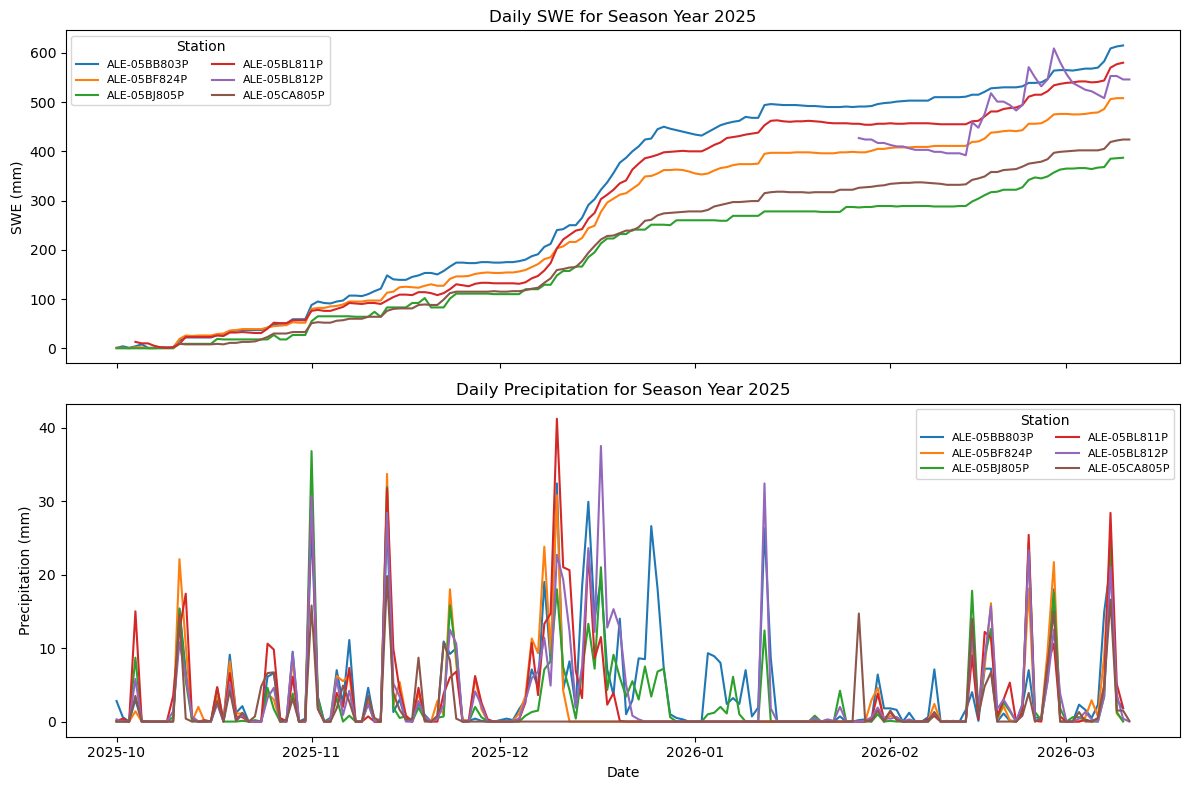

In [7]:
# plot daily SWE and precipitation for season 2025
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for station_id, group in season_2025_df.groupby('station_id'):
    axes[0].plot(group['time'], group['SWE'], label=station_id)
    axes[1].plot(group['time'], group['Precipitation'], label=station_id)

axes[0].set_title('Daily SWE for Season Year 2025')
axes[0].set_ylabel('SWE (mm)')
axes[0].legend(title='Station', ncol=2, fontsize=8)

axes[1].set_title('Daily Precipitation for Season Year 2025')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend(title='Station', ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# remove 05BL812
season_2025_df = season_2025_df[season_2025_df['station_id'] != 'ALE-05BL812P']
display(season_2025_df)

,station_id,time,SWE,Precipitation,month,year,Seasonal_Year
205,ALE-05BB803P,2025-10-01,1.0,2.8,10,2025,2025
206,ALE-05BB803P,2025-10-02,4.0,0.6,10,2025,2025
207,ALE-05BB803P,2025-10-03,1.0,0.0,10,2025,2025
208,ALE-05BB803P,2025-10-04,4.0,3.0,10,2025,2025
209,ALE-05BB803P,2025-10-05,8.0,0.0,10,2025,2025
...,...,...,...,...,...,...,...
2190,ALE-05CA805P,2026-03-07,405.0,4.8,3,2026,2025
2191,ALE-05CA805P,2026-03-08,419.0,16.6,3,2026,2025
2192,ALE-05CA805P,2026-03-09,422.0,1.5,3,2026,2025
2193,ALE-05CA805P,2026-03-10,424.0,1.5,3,2026,2025


In [9]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(season_2025_df['station_id'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']


get gapfilled data for SWEI timeseries

In [10]:
# open gapfilled and original CANSWE data 
gapfilled_ds = xr.open_dataset(config['gap_filled_canswe_data'])
original_ds = xr.open_dataset(config['canswe_original_data'])

# filter Elevation_Category = 2000_2500m from original_ds and merge with gapfilled_ds
original_df = original_ds.to_dataframe().reset_index()
original_df = original_df[original_df['Elevation_Category'] == '2000_2500m']
gapfilled_df = gapfilled_ds.to_dataframe().reset_index()
merged_df = pd.merge(
    original_df,
    gapfilled_df,
    on=['time', 'station_id'],
    how='outer',
    suffixes=('_original', '_gapfilled')
)

# drop lat_gapfilled, lon_gapfilled,station_name_gapfilled
merged_df = merged_df.drop(columns=['lat_gapfilled', 'lon_gapfilled', 'station_name_gapfilled'])
display(merged_df.head())

,time,station_id,snw,lat_original,lon_original,station_name_original,Elevation_Category,SWE
0,1980-01-02,ALE-05BA806,NaN,51.416620,-116.238270,MIRROR LAKE,2000_2500m,NaN
1,1980-01-02,ALE-05BA810,NaN,51.474090,-116.102745,PTARMIGAN HUT,2000_2500m,NaN
2,1980-01-02,ALE-05BA811,NaN,51.700000,-116.466670,BOW SUMMIT (OLD),2000_2500m,NaN
3,1980-01-02,ALE-05BA812,NaN,51.325010,-116.206170,LARCH VALLEY,2000_2500m,NaN
4,1980-01-02,ALE-05BA813,NaN,51.710014,-116.478070,BOW SUMMIT (NEW),2000_2500m,NaN


In [11]:
# assign Seasonal_Year to merged_df

def select_seasonal_data(ts, start_month, end_month, min_year, max_year):
    month = ts.month
    year = ts.year
    if month >= start_month:
        seasonal_year = year
    elif month <= end_month:
        seasonal_year = year - 1
    else:
        return np.nan
    return seasonal_year if (min_year <= seasonal_year <= max_year) else np.nan

# For CanSWE data
merged_df['Seasonal_Year'] = merged_df['time'].apply(
    lambda ts: select_seasonal_data(ts, start_month=10, end_month=9, min_year=1980, max_year=2023)
)

# drop rows with NaN Seasonal_Year
merged_df = merged_df.dropna(subset=['Seasonal_Year']).copy()

# drop snw,lat_original, lon_original, station_name_original, Elevation_Category
merged_df = merged_df.drop(columns=['snw', 'lat_original', 'lon_original', 'station_name_original', 'Elevation_Category'])

display(merged_df.head())

,time,station_id,SWE,Seasonal_Year
680,1980-11-27,ALE-05BA806,NaN,1980.0
681,1980-11-27,ALE-05BA810,NaN,1980.0
682,1980-11-27,ALE-05BA811,NaN,1980.0
683,1980-11-27,ALE-05BA812,NaN,1980.0
684,1980-11-27,ALE-05BA813,NaN,1980.0


In [12]:
#Filter to station_ids 'ALE-05BB803P','ALE-05BF824P','ALE-05BJ805P','ALE-05BL811P','ALE-05CA805P'
filtered_station = merged_df[
    merged_df['station_id'].isin([
        'ALE-05BB803P',
        'ALE-05BF824P',
        'ALE-05BJ805P',
        'ALE-05BL811P',
        'ALE-05CA805P'
    ])
].copy()
display(filtered_station.head())

,time,station_id,SWE,Seasonal_Year
687,1980-11-27,ALE-05BB803P,NaN,1980.0
691,1980-11-27,ALE-05BF824P,NaN,1980.0
693,1980-11-27,ALE-05BJ805P,NaN,1980.0
696,1980-11-27,ALE-05BL811P,NaN,1980.0
700,1980-11-27,ALE-05CA805P,NaN,1980.0


In [13]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(filtered_station['station_id'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']


In [14]:
# add season_2025_df data to the bottom of filtered_station
final_df = pd.concat([filtered_station, season_2025_df], ignore_index=True)
#drop month, year, Precipitation columns from final_df
final_df = final_df.drop(columns=['month', 'year', 'Precipitation'])
display(final_df.head())

,time,station_id,SWE,Seasonal_Year
0,1980-11-27,ALE-05BB803P,NaN,1980.0
1,1980-11-27,ALE-05BF824P,NaN,1980.0
2,1980-11-27,ALE-05BJ805P,NaN,1980.0
3,1980-11-27,ALE-05BL811P,NaN,1980.0
4,1980-11-27,ALE-05CA805P,NaN,1980.0


In [15]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(final_df['station_id'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']


In [16]:
season_2025_weekly = final_df[final_df['Seasonal_Year'] == 2025].copy()
display(season_2025_weekly.head())

,time,station_id,SWE,Seasonal_Year
80050,2025-10-01,ALE-05BB803P,1.0,2025.0
80051,2025-10-02,ALE-05BB803P,4.0,2025.0
80052,2025-10-03,ALE-05BB803P,1.0,2025.0
80053,2025-10-04,ALE-05BB803P,4.0,2025.0
80054,2025-10-05,ALE-05BB803P,8.0,2025.0


# Classification

In [17]:
# calculate running monthly SWE and cumulative precipitation 
def calculate_running_oct_may_swe_precip(
    df,
    time_col='time',
    station_col='station_id',
    swe_col='SWE',
    precip_col='Precipitation',
    season_col='Seasonal_Year'
):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    # keep only Oct-May
    out = out[out[time_col].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])].copy()

    # if Seasonal_Year is not already there, create it
    if season_col not in out.columns:
        out['month'] = out[time_col].dt.month
        out['year'] = out[time_col].dt.year
        out[season_col] = out['year']
        out.loc[out['month'].isin([1, 2, 3, 4, 5]), season_col] = (
            out.loc[out['month'].isin([1, 2, 3, 4, 5]), 'year'] - 1
        )

    out['month'] = out[time_col].dt.month

    # season month order: Oct=1, Nov=2, ..., May=8
    season_month_map = {10: 1, 11: 2, 12: 3, 1: 4, 2: 5, 3: 6, 4: 7, 5: 8}
    out['season_month_order'] = out['month'].map(season_month_map)

    results = []

    for (station_id, seasonal_year), group in out.groupby([station_col, season_col], dropna=False):
        group = group.sort_values(time_col).copy()

        for current_order in range(1, 9):
            subset = group[group['season_month_order'] <= current_order].copy()

            if subset.empty:
                continue

            current_month = [k for k, v in season_month_map.items() if v == current_order][0]

            results.append({
                station_col: station_id,
                season_col: seasonal_year,
                'month': current_month,
                'season_month_order': current_order,
                'mean_SWE': subset[swe_col].mean(skipna=True),
                'cumulative_P': subset[precip_col].sum(skipna=True)
            })

    result_df = pd.DataFrame(results).sort_values(
        [station_col, season_col, 'season_month_order']
    ).reset_index(drop=True)

    return result_df

In [18]:
#calculate running monthly SWE and cumulative precipitation for season 2025
classification_df = calculate_running_oct_may_swe_precip(season_2025_df)

# caculate mean_SWE/Cum_P
classification_df['SWE_P_ratio'] = classification_df['mean_SWE'] / classification_df['cumulative_P']



display(classification_df.head(12))

,station_id,Seasonal_Year,month,season_month_order,mean_SWE,cumulative_P,SWE_P_ratio
0,ALE-05BB803P,2025,10,1,25.548387,67.2,0.380184
1,ALE-05BB803P,2025,11,2,79.885246,189.6,0.421336
2,ALE-05BB803P,2025,12,3,157.510870,461.9,0.341006
3,ALE-05BB803P,2025,1,4,238.487805,550.3,0.433378
4,ALE-05BB803P,2025,2,5,290.947020,619.5,0.469648
5,ALE-05BB803P,2025,3,6,309.031056,667.3,0.463107
6,ALE-05BB803P,2025,4,7,309.031056,667.3,0.463107
7,ALE-05BB803P,2025,5,8,309.031056,667.3,0.463107
8,ALE-05BF824P,2025,10,1,25.225806,65.1,0.387493
9,ALE-05BF824P,2025,11,2,70.295082,204.2,0.344246


In [19]:
# drop months 4 and 5 (April and May) for the report
classification_df = classification_df[~classification_df['month'].isin([4, 5])].copy()
display(classification_df)

,station_id,Seasonal_Year,month,season_month_order,mean_SWE,cumulative_P,SWE_P_ratio
0,ALE-05BB803P,2025,10,1,25.548387,67.2,0.380184
1,ALE-05BB803P,2025,11,2,79.885246,189.6,0.421336
2,ALE-05BB803P,2025,12,3,157.510870,461.9,0.341006
3,ALE-05BB803P,2025,1,4,238.487805,550.3,0.433378
4,ALE-05BB803P,2025,2,5,290.947020,619.5,0.469648
5,ALE-05BB803P,2025,3,6,309.031056,667.3,0.463107
8,ALE-05BF824P,2025,10,1,25.225806,65.1,0.387493
9,ALE-05BF824P,2025,11,2,70.295082,204.2,0.344246
10,ALE-05BF824P,2025,12,3,134.217391,297.6,0.450999
11,ALE-05BF824P,2025,1,4,197.878049,305.1,0.648568


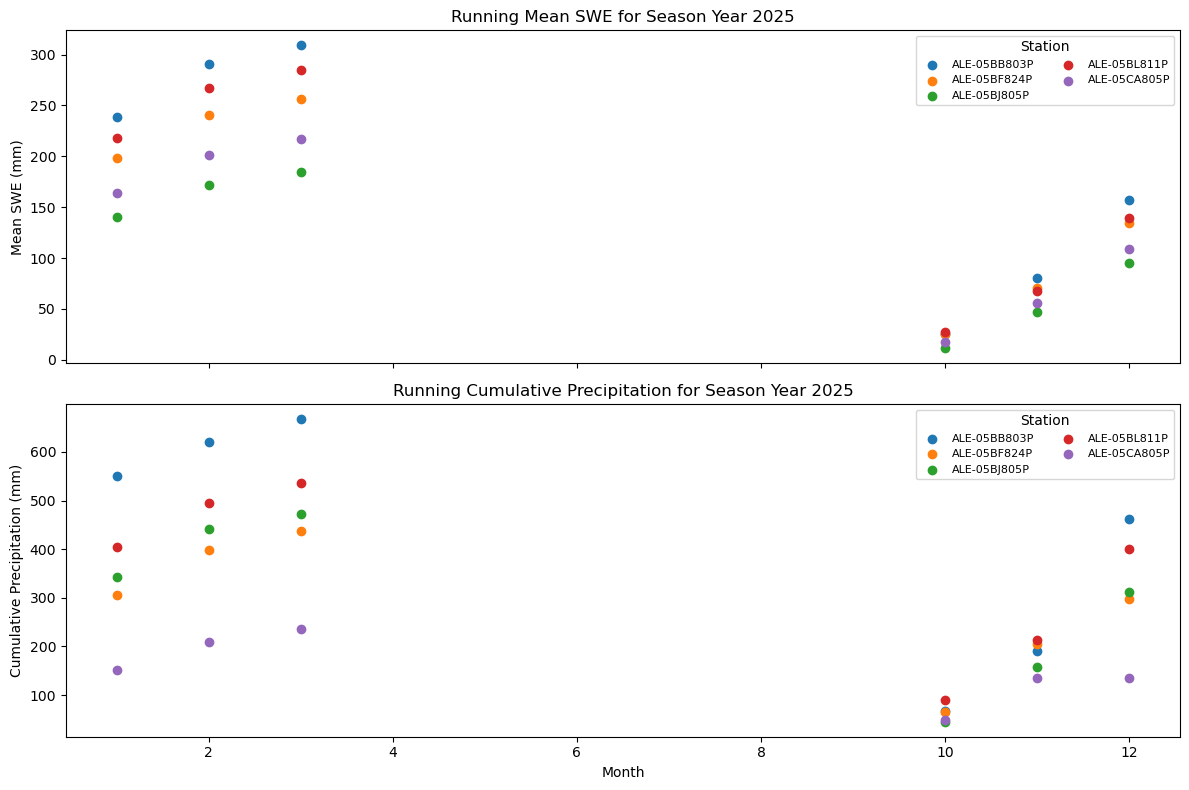

In [20]:
# plot monthly SWE and cumulative precipitation for season 2025
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for station_id, group in classification_df.groupby('station_id'):
    axes[0].scatter(group['month'], group['mean_SWE'], marker='o', label=station_id)
    axes[1].scatter(group['month'], group['cumulative_P'], marker='o', label=station_id)
axes[0].set_title('Running Mean SWE for Season Year 2025')
axes[0].set_ylabel('Mean SWE (mm)')
axes[0].legend(title='Station', ncol=2, fontsize=8)
axes[1].set_title('Running Cumulative Precipitation for Season Year 2025')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cumulative Precipitation (mm)')
axes[1].legend(title='Station', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
def calculate_monthly_swe_precip_resample(
    df,
    time_col='time',
    station_col='station_id',
    swe_col='SWE',
    precip_col='Precipitation'
):
    out = df.copy()
    out[time_col] = pd.to_datetime(out[time_col], errors='coerce')

    monthly = (
        out.set_index(time_col)
           .groupby(station_col)
           .resample('M')
           .agg({
               swe_col: 'mean',
               precip_col: 'sum'
           })
           .rename(columns={
               swe_col: 'mean_SWE',
               precip_col: 'cumulative_P'
           })
           .reset_index()
    )

    monthly['year'] = monthly[time_col].dt.year
    monthly['month'] = monthly[time_col].dt.month

    if 'Seasonal_Year' in out.columns:
        monthly['Seasonal_Year'] = monthly[time_col].dt.year
        monthly.loc[monthly['month'].isin([1, 2, 3, 4, 5]), 'Seasonal_Year'] = (
            monthly.loc[monthly['month'].isin([1, 2, 3, 4, 5]), time_col].dt.year - 1
        )
        monthly.loc[monthly['month'].isin([10, 11, 12]), 'Seasonal_Year'] = (
            monthly.loc[monthly['month'].isin([10, 11, 12]), time_col].dt.year
        )

    return monthly

monthly_df = (
    season_2025_df
    .groupby(['station_id', 'Seasonal_Year', season_2025_df['time'].dt.month], dropna=False)
    .agg(
        mean_SWE=('SWE_change', 'mean'),
        cumulative_P=('Precipitation', 'sum')
    )
    .reset_index()
    .rename(columns={'time': 'month'})
)

display(monthly_df.head())

KeyError: "Column(s) ['SWE_change'] do not exist"

# Calculate SWEI

In [23]:
# monthly SWEI calculation functions 

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id"]]
        .drop_duplicates("station_id")
        .set_index("station_id")
    )


def daily_to_monthly_swe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Daily SWE → monthly integrated SWE.
    Seasonal_Year is recomputed from time.
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    monthly = (
        out
        .groupby(
            ["station_id", pd.Grouper(key="time", freq="MS")],
            as_index=False
        )
        .agg(
            SWE_monthly=("SWE", "sum")
        )
    )

    # Recompute Seasonal_Year (e.g., Oct–Sep water year)
    monthly["Seasonal_Year"] = np.where(
        monthly["time"].dt.month >= 10,
        monthly["time"].dt.year,
        monthly["time"].dt.year - 1
    )

    return monthly



def rolling_integrated_swe_by_season(
    monthly_df: pd.DataFrame,
    window_months: int
) -> pd.DataFrame:
    """
    Compute rolling k‑month integrated SWE within each Seasonal_Year.

    • Rolling windows do NOT cross Seasonal_Year boundaries.
    • First (k‑1) months of each season are dropped.
    • Works for any window (3, 6, 8, …).
    """

    out = monthly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_months}mo"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_monthly"]
        .rolling(window=window_months, min_periods=window_months)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_months}mo"])



def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    # ranks with average ties
    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute SWEI for ONE Grid_id using calendar-month standardization.
    """
    out = df.copy()
    out["month"] = out["time"].dt.month

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for m in range(1, 13):
        idx = out["month"] == m
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue  # Near-normal (NN)

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out



def compute_swei(
    df: pd.DataFrame,
    window_months: int = 3
) -> pd.DataFrame:
    """
    End‑to‑end SWEI calculation with metadata preservation.
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily → monthly SWE
    monthly = daily_to_monthly_swe(df)

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season(monthly, window_months)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid(
                g,
                swe_col=f"SWE_{window_months}mo"
            )
        )
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei


def plot_seasonal_sswei_maps(
    swei_df,
    basin_gdf,
    config,
    window_label="3-month",
    swei_col="Avg_SWEI_3mo",
    start_year=1980,
    end_year=2024,
    month_order=(10, 11, 12, 1, 2, 3, 4, 5),
    month_names=None,
    classify_func=None,
    severity_colors=None,
    nrows=2,
    ncols=3,
    figsize=(20, 10),
    dpi=300
):
    """
    Plot seasonal SSWEI maps for each Seasonal_Year.

    Parameters
    ----------
    swei_df : pandas.DataFrame
        DataFrame containing SSWEI values with columns:
        ['Seasonal_Year', 'month', 'Elevation_Category', swei_col].
    basin_gdf : geopandas.GeoDataFrame
        Basin polygons with elevation categories column 'elev_class'.
    config : dict
        Configuration dictionary containing output directory path:
        config['SWEI_plots'].
    window_label : str
        Text label for SWEI window (e.g., '3-month', '6-month', '8-month').
    swei_col : str
        Column name containing SSWEI values.
    start_year, end_year : int
        Seasonal_Year range to plot (end_year is exclusive).
    month_order : iterable
        Ordered months for snow season (default Oct–May).
    month_names : dict
        Mapping of month number → month name.
    classify_func : callable
        Function that maps SSWEI → drought class.
    severity_colors : dict
        Mapping of drought class → color.
    nrows, ncols : int
        Subplot grid dimensions.
    figsize : tuple
        Figure size.
    dpi : int
        Output resolution.
    """

    if month_names is None:
        month_names = {
            1: "January", 2: "February", 3: "March", 4: "April",
            5: "May", 10: "October", 11: "November", 12: "December"
        }

    if classify_func is None or severity_colors is None:
        raise ValueError("Both classify_func and severity_colors must be provided.")

    for season_year in range(start_year, end_year):

        # Subset data for this season
        swei_year = swei_df[swei_df["Seasonal_Year"] == season_year]
        if swei_year.empty:
            continue

        # Determine months present and in correct order
        available_months = swei_year["month"].unique().tolist()
        months_year = [m for m in month_order if m in available_months]
        n_months = len(months_year)

        # Create subplot grid
        fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
        axes = axes.flatten()

        for idx, month in enumerate(months_year):
            ax = axes[idx]

            # Subset month data
            month_data = swei_year[swei_year["month"] == month]

            # Prepare elevation-band SSWEI table
            sswei_long = (
                month_data[["Elevation_Category", swei_col]]
                .rename(columns={swei_col: "SSWEI"})
            )

            # Merge with basin geometry
            basin_plot = basin_gdf.merge(
                sswei_long,
                left_on="elev_class",
                right_on="Elevation_Category",
                how="left"
            )

            # Classify SSWEI and assign colors
            basin_plot["Drought_Classification"] = (
                basin_plot["SSWEI"].apply(classify_func)
            )
            basin_plot["color"] = (
                basin_plot["Drought_Classification"]
                .map(severity_colors)
                .fillna("#dddddd")
            )

            # Plot
            basin_plot.plot(
                ax=ax,
                color=basin_plot["color"],
                edgecolor="black",
                linewidth=0.5
            )

            # Display year logic
            display_year = season_year if month >= 10 else season_year + 1

            ax.set_title(
                f"{month_names.get(month, str(month))} {display_year}",
                fontsize=12,
                fontweight="bold"
            )
            ax.axis("off")

        # Hide unused axes
        for j in range(n_months, len(axes)):
            axes[j].set_visible(False)

        # Figure title and legend
        fig.suptitle(
            f"{window_label} SSWEI Distribution across Bow River Basin "
            f"(Season {season_year})",
            fontsize=16,
            fontweight="bold",
            y=0.98
        )

        legend_handles = [
            mpatches.Patch(color=c, label=l)
            for l, c in severity_colors.items()
        ]
        fig.legend(
            handles=legend_handles,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            title="Drought Severity"
        )

        plt.tight_layout()

        # Save output
        out_file = (
            config["SWEI_plots"]
            / f"SSWEI_bow_basin_monthly_{window_label.replace(' ', '_')}_{season_year}.png"
        )
        fig.savefig(out_file, dpi=dpi, bbox_inches="tight")
        plt.close(fig)



In [47]:
# 1-month SWEI
swei_1mo = compute_swei(final_df, window_months=1)
swei_1mo_output_dir = config['output_plots'] / 'swei_1mo'
swei_1mo_output_dir.mkdir(parents=True, exist_ok=True)
swei_1mo.to_csv(swei_1mo_output_dir / 'swei_1mo.csv', index=False)

display(swei_1mo)

,station_id,time,SWE_monthly,Seasonal_Year,SWE_1mo,month,Gringorten_p,SWEI
0,ALE-05BB803P,1980-10-01,0.0,1980,0.0,10,0.056738,-1.582764
1,ALE-05BB803P,1980-11-01,0.0,1980,0.0,11,0.056738,-1.582764
2,ALE-05BB803P,1980-12-01,0.0,1980,0.0,12,0.056738,-1.582764
3,ALE-05BB803P,1981-01-01,0.0,1980,0.0,1,0.045656,-1.688517
4,ALE-05BB803P,1981-02-01,0.0,1980,0.0,2,0.045656,-1.688517
...,...,...,...,...,...,...,...,...
2655,ALE-05CA805P,2025-11-01,2462.0,2025,2462.0,11,0.699468,0.522871
2656,ALE-05CA805P,2025-12-01,6133.0,2025,6133.0,12,0.921099,1.412505
2657,ALE-05CA805P,2026-01-01,9611.0,2025,9611.0,1,0.965426,1.817445
2658,ALE-05CA805P,2026-02-01,9870.0,2025,9870.0,2,0.965426,1.817445


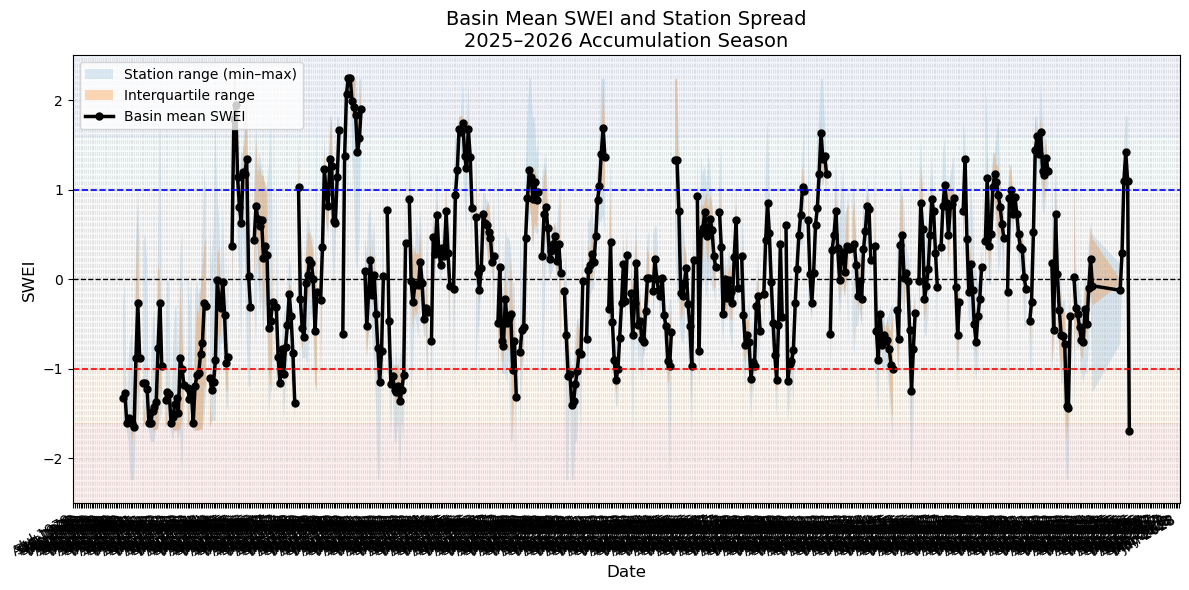

In [63]:
season_2025_Monthly = swei_1mo[swei_1mo['Seasonal_Year'] == 2025].copy()
season_2025_Monthly['time'] = pd.to_datetime(season_2025_Monthly['time'])

# remove March  for the report
season_2025_Monthly = season_2025_Monthly[~season_2025_Monthly['time'].dt.month.isin([3])].copy()

basin_stats = (
    swei_1mo
    .groupby('time')['SWEI']
    .agg(
        mean='mean',
        min='min',
        max='max',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
    .sort_values('time')
)

fig, ax = plt.subplots(figsize=(12, 6))

# Background zones
ax.axhspan(-2.5, -1.6, color='red', alpha=0.06)
ax.axhspan(-1.6, -1.0, color='orange', alpha=0.06)
ax.axhspan(-1.0,  1.0, color='grey', alpha=0.04)
ax.axhspan( 1.0,  1.6, color='skyblue', alpha=0.06)
ax.axhspan( 1.6,  2.5, color='royalblue', alpha=0.06)

# Full spread
ax.fill_between(
    basin_stats['time'],
    basin_stats['min'],
    basin_stats['max'],
    alpha=0.15,
    label='Station range (min–max)'
)

# Interquartile spread
ax.fill_between(
    basin_stats['time'],
    basin_stats['q25'],
    basin_stats['q75'],
    alpha=0.30,
    label='Interquartile range'
)

# Mean line
ax.plot(
    basin_stats['time'],
    basin_stats['mean'],
    color='black',
    linewidth=2.5,
    marker='o',
    markersize=5,
    label='Basin mean SWEI'
)

# Thresholds
ax.axhline(-1.0, color='red', linestyle='--', linewidth=1.2)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0)
ax.axhline(1.0, color='blue', linestyle='--', linewidth=1.2)

ax.set_title('Basin Mean SWEI and Station Spread\n2025–2026 Accumulation Season', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)
ax.set_ylim(-2.5, 2.5)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

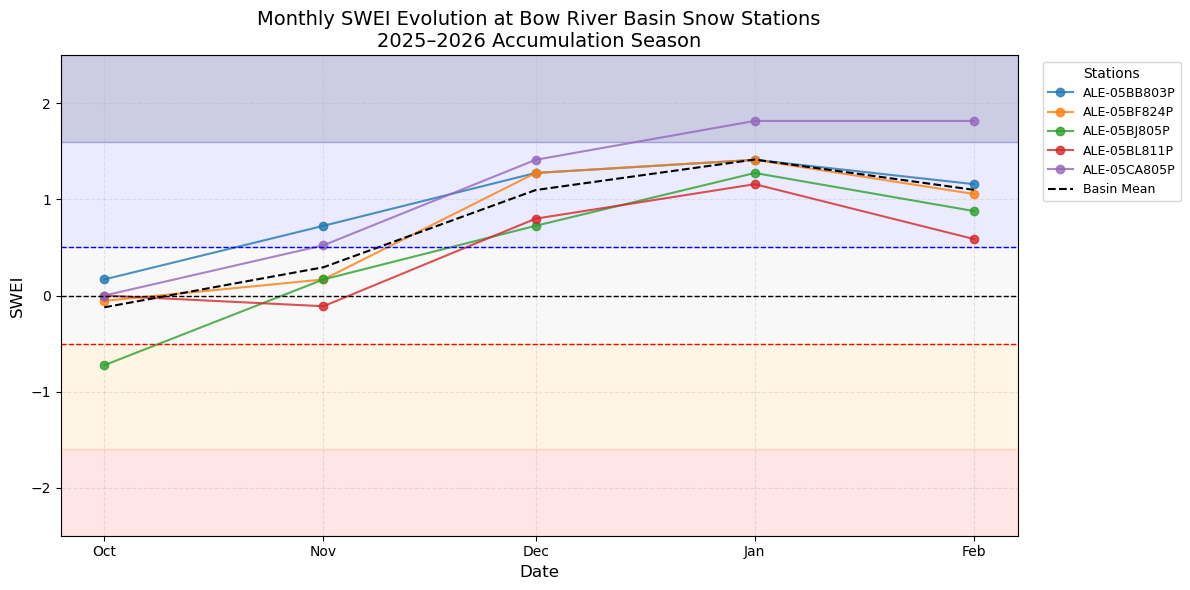

In [69]:
# plot for monthly SWEI season 2025
season_2025_Monthly = swei_1mo[swei_1mo['Seasonal_Year'] == 2025].copy()

# remove March  for the report
season_2025_Monthly = season_2025_Monthly[~season_2025_Monthly['time'].dt.month.isin([3])].copy()


fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_id, group in season_2025_Monthly.groupby('station_id'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_id)
    

# --- optional basin mean ---
basin_mean = season_2025_Monthly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='--',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1)

# --- labels ---
ax.set_title('Monthly SWEI Evolution at Bow River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Stations',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# weekly SWEI calculation functions

def extract_grid_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract per-Grid static metadata.
    """
    return (
        df[["station_id"]]
        .drop_duplicates("station_id")
        .set_index("station_id")
    )


def daily_to_weekly_swe(
    df: pd.DataFrame,
    week_freq: str = "W-SUN",
    weekly_agg: str = "last"
) -> pd.DataFrame:
    """
    Daily SWE -> weekly SWE.

    Parameters
    ----------
    week_freq : str
        Weekly resampling frequency, e.g. 'W-SUN', 'W-MON'
    weekly_agg : str
        Aggregation within week: 'last', 'mean', or 'max'

    Returns
    -------
    DataFrame with columns:
        station_id, time, SWE_weekly, Seasonal_Year, season_week
    """
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])

    if weekly_agg == "last":
        weekly = (
            out.set_index("time")
            .groupby("station_id")["SWE"]
            .resample(week_freq)
            .last()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "mean":
        weekly = (
            out.set_index("time")
            .groupby("Grid_id")["SWE"]
            .resample(week_freq)
            .mean()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    elif weekly_agg == "max":
        weekly = (
            out.set_index("time")
            .groupby("Grid_id")["SWE"]
            .resample(week_freq)
            .max()
            .reset_index()
            .rename(columns={"SWE": "SWE_weekly"})
        )
    else:
        raise ValueError("weekly_agg must be one of: 'last', 'mean', 'max'")

    # Recompute Seasonal_Year using Oct-May style start year
    # Oct 2025 - May 2026 => Seasonal_Year = 2025
    weekly["Seasonal_Year"] = np.where(
        weekly["time"].dt.month >= 10,
        weekly["time"].dt.year,
        weekly["time"].dt.year - 1
    )

    # Define season start = Oct 1 of Seasonal_Year
    season_start = pd.to_datetime(weekly["Seasonal_Year"].astype(str) + "-10-01")

    # season_week = week number within season
    weekly["season_week"] = ((weekly["time"] - season_start).dt.days // 7) + 1

    # Optional: keep only Oct-May season weeks
    weekly = weekly[
        weekly["time"].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])
    ].copy()

    return weekly


def rolling_integrated_swe_by_season_weekly(
    weekly_df: pd.DataFrame,
    window_weeks: int
) -> pd.DataFrame:
    """
    Compute rolling k-week integrated SWE within each Seasonal_Year.

    - Rolling windows do NOT cross Seasonal_Year boundaries.
    - First (k-1) weeks of each season are dropped.
    """
    out = weekly_df.copy()
    out = out.sort_values(["station_id", "Seasonal_Year", "time"])

    out[f"SWE_{window_weeks}wk"] = (
        out
        .groupby(["station_id", "Seasonal_Year"])["SWE_weekly"]
        .rolling(window=window_weeks, min_periods=window_weeks)
        .sum()
        .reset_index(level=[0, 1], drop=True)
    )

    return out.dropna(subset=[f"SWE_{window_weeks}wk"])


def gringorten_probabilities(x: np.ndarray) -> np.ndarray:
    """
    Gringorten plotting position with:
    - NaN handling
    - average ranks for ties
    - probability clipping
    """
    x = np.asarray(x, float)
    out = np.full_like(x, np.nan)

    mask = ~np.isnan(x)
    xv = x[mask]

    if xv.size == 0:
        return out

    order = np.argsort(xv, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(xv) + 1)

    uvals, inv, cnt = np.unique(xv, return_inverse=True, return_counts=True)
    for i, c in enumerate(cnt):
        if c > 1:
            idx = np.where(inv == i)[0]
            ranks[idx] = ranks[idx].mean()

    N = float(len(xv))
    p = (ranks - 0.44) / (N + 0.12)
    p = np.clip(p, 1e-12, 1 - 1e-12)

    out[mask] = p
    return out


def compute_swei_for_grid_weekly(
    df: pd.DataFrame,
    swe_col: str,
    nonzero_frac_threshold: float = 0.75
) -> pd.DataFrame:
    """
    Compute weekly SWEI for ONE station_id using season-week standardization.

    Each week is standardized against the historical distribution of
    the same season_week for that station.
    """
    out = df.copy()

    pvals = np.full(len(out), np.nan)
    zvals = np.full(len(out), np.nan)

    for wk in sorted(out["season_week"].dropna().unique()):
        idx = out["season_week"] == wk
        vals = out.loc[idx, swe_col]

        valid = vals.notna()
        if valid.sum() == 0:
            continue

        frac_nonzero = (vals[valid] > 0).mean()
        if frac_nonzero < nonzero_frac_threshold:
            continue

        p = gringorten_probabilities(vals.values)
        z = norm.ppf(p)

        pvals[idx] = p
        zvals[idx] = z

    out["Gringorten_p"] = pvals
    out["SWEI"] = zvals
    return out


def compute_weekly_swei(
    df: pd.DataFrame,
    window_weeks: int = 4,
    week_freq: str = "W-SUN",
    weekly_agg: str = "last"
) -> pd.DataFrame:
    """
    End-to-end weekly SWEI calculation with metadata preservation.

    Steps:
    1. Daily -> weekly SWE
    2. Rolling k-week integrated SWE within season
    3. Compute SWEI per Grid_id using season-week climatology
    4. Reattach static metadata
    """

    # 0. Extract static grid metadata
    grid_meta = extract_grid_metadata(df)

    # 1. Daily -> weekly SWE
    weekly = daily_to_weekly_swe(
        df,
        week_freq=week_freq,
        weekly_agg=weekly_agg
    )

    # 2. Rolling integration
    integ = rolling_integrated_swe_by_season_weekly(weekly, window_weeks)

    # 3. Compute SWEI per grid
    swei = (
        integ
        .groupby("station_id", group_keys=False)
        .apply(
            lambda g: compute_swei_for_grid_weekly(
                g,
                swe_col=f"SWE_{window_weeks}wk"
            )
        )
        .reset_index(drop=True)
    )

    # 4. Reattach static metadata
    swei = swei.join(grid_meta, on="station_id")

    return swei

In [26]:
#Weekly SWEI historic SWEI calculation
weekly_swei = compute_weekly_swei(
    df=final_df,
    window_weeks=1,      # 1-week SWEI
    week_freq="W-SUN",   # weekly ending Sunday
    weekly_agg="last"    # recommended for SWE
)

display(weekly_swei.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI
0,ALE-05BB803P,1981-03-22,493.24,1980,25,493.24,0.352675,-0.378110
1,ALE-05BB803P,1981-03-29,499.15,1980,26,499.15,0.262013,-0.637153
2,ALE-05BB803P,1981-04-05,537.79,1980,27,537.79,0.398005,-0.258513
3,ALE-05BB803P,1981-04-12,554.87,1980,28,554.87,0.420671,-0.200177
4,ALE-05BB803P,1981-04-19,558.55,1980,29,558.55,0.330009,-0.439888


In [27]:
# print unique station_ids in weekly_swei
print("Unique station_ids in weekly_swei:")
print(weekly_swei['station_id'].unique())

Unique station_ids in weekly_swei:
['ALE-05BB803P' 'ALE-05BF824P' 'ALE-05BJ805P' 'ALE-05BL811P'
 'ALE-05CA805P']


In [28]:
season_2025_weekly = weekly_swei[weekly_swei['Seasonal_Year'] == 2025].copy()
display(season_2025_weekly.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI
1419,ALE-05BB803P,2025-10-05,8.0,2025,1,8.0,0.539349,0.098795
1420,ALE-05BB803P,2025-10-12,22.0,2025,2,22.0,0.686939,0.487193
1421,ALE-05BB803P,2025-10-19,35.0,2025,3,35.0,0.612164,0.284962
1422,ALE-05BB803P,2025-10-26,49.0,2025,4,49.0,0.637089,0.350688
1423,ALE-05BB803P,2025-11-02,95.0,2025,5,95.0,0.811565,0.883679


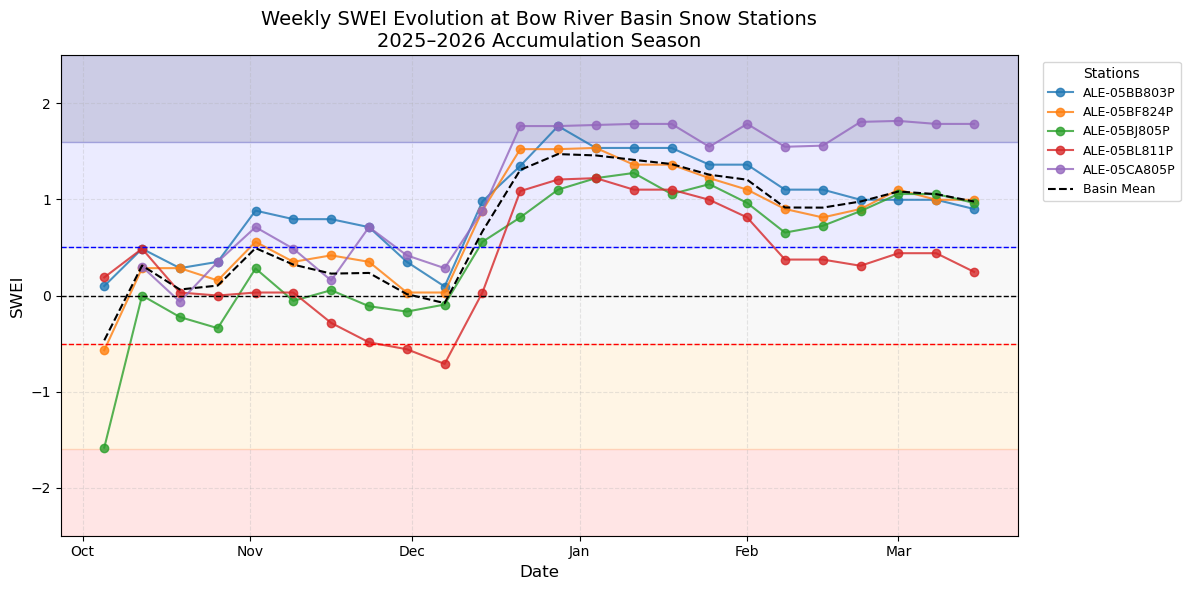

In [70]:
# plot for season 2025
season_2025_weekly = weekly_swei[weekly_swei['Seasonal_Year'] == 2025].copy()

fig, ax = plt.subplots(figsize=(12,6))

# --- plot station lines (lighter) ---
for station_id, group in season_2025_weekly.groupby('station_id'):
    ax.plot(group['time'], group['SWEI'],
            marker='o', linewidth=1.5, alpha=0.8,
            label=station_id)

# --- optional basin mean ---
basin_mean = season_2025_weekly.groupby('time')['SWEI'].mean()
ax.plot(basin_mean.index, basin_mean.values,
        color='black', linewidth=1.5, linestyle='--',
        label='Basin Mean')

# --- drought/wet shading ---
ax.axhspan(-2.5, -1.6, color='red', alpha=0.1)
ax.axhspan(-1.6, -0.5, color='orange', alpha=0.1)
ax.axhspan(-0.5, 0.5, color='grey', alpha=0.05)
ax.axhspan(0.5, 1.6, color='blue', alpha=0.08)
ax.axhspan(1.6, 2.5, color='navy', alpha=0.2)

# --- key threshold lines ---
ax.axhline(-0.5, color='red', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1)
# --- labels ---
ax.set_title('Weekly SWEI Evolution at Bow River Basin Snow Stations\n2025–2026 Accumulation Season',
             fontsize=14)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('SWEI', fontsize=12)

# --- monthly ticks ---
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# --- limits ---
ax.set_ylim(-2.5,2.5)

# --- grid ---
ax.grid(True, linestyle='--', alpha=0.3)

# --- legend outside ---
ax.legend(title='Stations',
          bbox_to_anchor=(1.02,1),
          loc='upper left',
          fontsize=9)

plt.tight_layout()
plt.show()

In [30]:
#Average weekly SWEI
avg_weekly_swei = (
    weekly_swei
    .groupby(["Seasonal_Year", "season_week"], dropna=False)
    .agg(Avg_SWEI_1wk=("SWEI", "mean"))
    .reset_index()
)
display(avg_weekly_swei.head(12))

,Seasonal_Year,season_week,Avg_SWEI_1wk
0,1980,1,-0.281445
1,1980,2,-0.587694
2,1980,3,-1.817445
3,1980,4,0.655088
4,1980,5,0.167443
5,1980,6,1.056412
6,1980,7,0.655088
7,1980,8,0.878942
8,1980,9,0.460176
9,1980,15,-0.460176


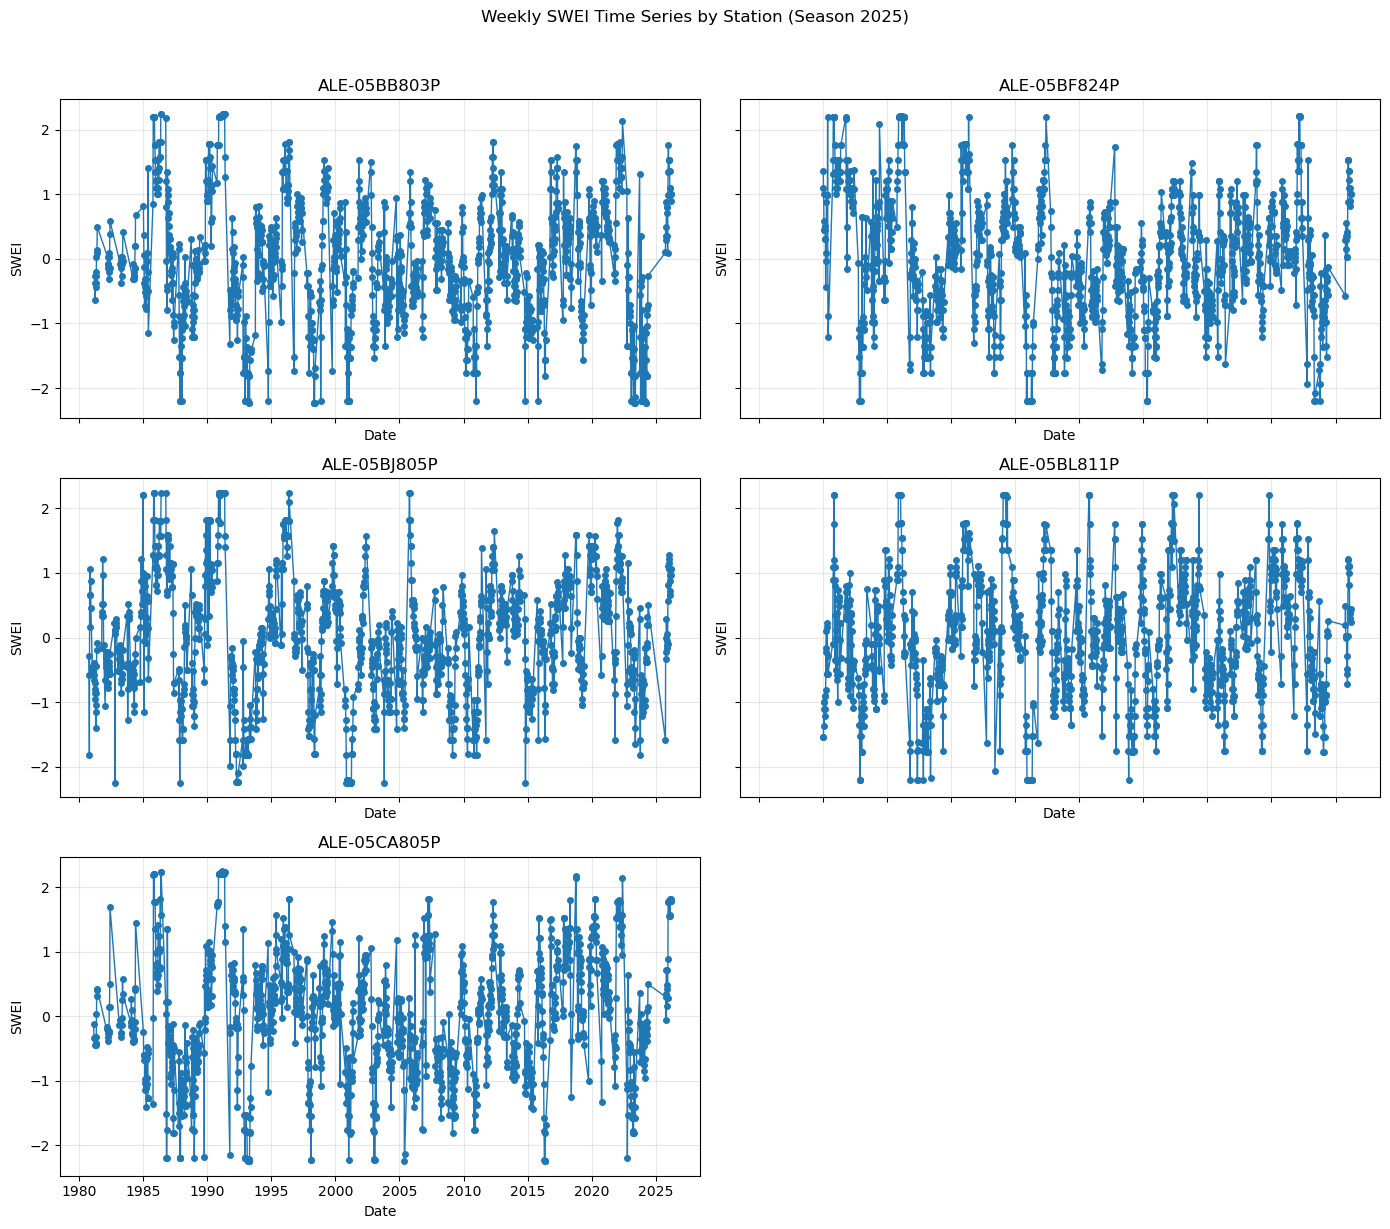

In [32]:
# plot Weekly SWEI time series for each station
# subset to stations with valid SWEI values
valid_stations = weekly_swei.loc[weekly_swei["SWEI"].notna(), "station_id"].unique()
weekly_swei_valid = weekly_swei[weekly_swei["station_id"].isin(valid_stations)].copy()

n_stations = len(valid_stations)
ncols = 2
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, station_id in enumerate(valid_stations):
    ax = axes[i]
    group = weekly_swei_valid[weekly_swei_valid["station_id"] == station_id].sort_values("time")
    ax.plot(group["time"], group["SWEI"], marker="o", markersize=4, linewidth=1)
    ax.set_title(station_id)
    ax.set_ylabel("SWEI")
    ax.grid(alpha=0.3)

for j in range(n_stations, len(axes)):
    axes[j].set_visible(False)

for ax in axes[:n_stations]:
    ax.set_xlabel("Date")
#ax.get_xlim(2025-10,2026-3)
fig.suptitle("Weekly SWEI Time Series by Station (Season 2025)", y=1.02)
plt.tight_layout()
plt.show()